# Tutorial 4: Model Data Overfitting and Gradient Descent

## Question 1:  Data Model Overfitting

Assume a two-dimensional dataset containing 10,000 labeled instances, each of which is assigned to one of two 
classes, 0 or 1. Instances from each class are generated as follows:
1. Instances from class 1 are generated from a mixture of 4 Gaussian distributions, centered at [5,15], [15,15],
and [15,5], [5. 5] with covariance of 2 with zero mean respectively. 
2. Instances from class 0 are generated from a uniform distribution in a square region, whose sides have a length equals to 20.

For simplicity, both classes have equal number of labeled instances. 
All instances from class 1 are shown in red while those from class 0 are shown in black.

**<font color="red">Code:Create Dataset</font>**

(10000, 2)


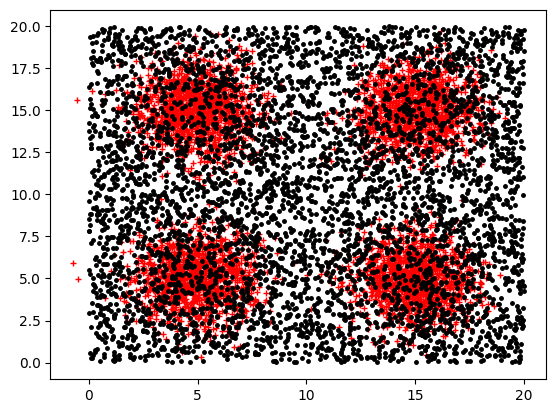

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import random

N = 10000

mean1 = [5, 15]
mean2 = [15, 15]
mean3 = [15, 5]
mean4 = [5, 5]

cov = [[2, 0], [0, 2]]  # diagonal covariance

np.random.seed(500)
X = np.random.multivariate_normal(mean1, cov, int(N/8))
X = np.concatenate((X, np.random.multivariate_normal(mean2, cov, int(N/8))))
X = np.concatenate((X, np.random.multivariate_normal(mean3, cov, int(N/8))))
X = np.concatenate((X, np.random.multivariate_normal(mean4, cov, int(N/8))))
X = np.concatenate((X, 20*np.random.rand(int(N/2),2)))
Y = np.concatenate((np.ones(int(N/2)),np.zeros(int(N/2))))
print(X.shape)
plt.plot(X[:int(N/2),0],X[:int(N/2),1],'r+',X[int(N/2):,0],X[int(N/2):,1],'k.',ms=5)

**<font color="red">Code:Split Data into Training and Test Set</font>**

In [5]:
###########################################################
# Create the Training and Test set with split 70:30 
##########################################################

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=12)

from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**<font color="red">Code:Create Decision Tree classifier and test the performance</font>**

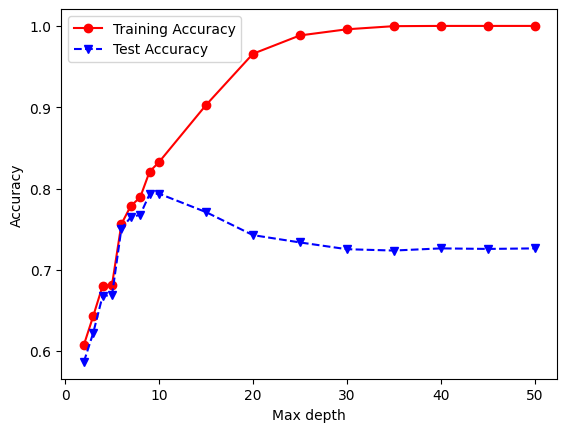

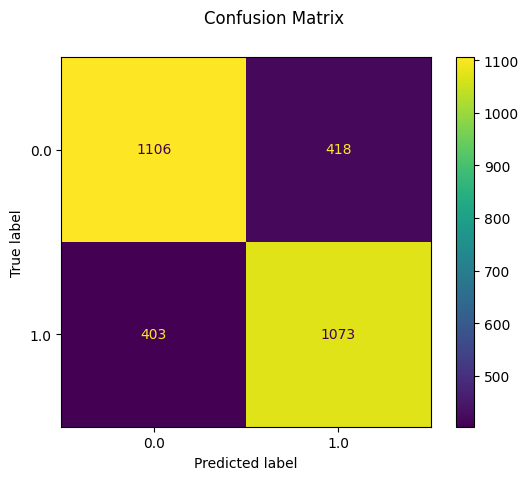

In [6]:
###########################################################################
# Model fit and performance evaluation for various tree depth from 2-50
###########################################################################

maxdepths = [2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50]

trainAccuracy = np.zeros(len(maxdepths))
testAccuracy = np.zeros(len(maxdepths))

index = 0
for depth in maxdepths:
    clf = tree.DecisionTreeClassifier(max_depth=depth)
    clf = clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    trainAccuracy[index] = accuracy_score(Y_train, Y_predTrain)
    testAccuracy[index] = accuracy_score(Y_test, Y_predTest)
    index += 1
    
###########################################################################
# Plot training and test accuracies
##########################################################################
    
plt.plot(maxdepths,trainAccuracy,'ro-',maxdepths,testAccuracy,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
disp = ConfusionMatrixDisplay.from_predictions(Y_test, Y_predTest)
disp.figure_.suptitle("Confusion Matrix")
plt.show()

Observation:

Training Accuracy approach 100% as depth increases but test accurcay drops as depth increase (i.e.the model becomes
more complex). The test accuracy initially improves up to a maximum depth of 10, before it gradually decreases due
to model overfitting. The confusion matrix shows false positive and false negative of 418 and 403 respectively, highlighting (418+403) out of 3000 data sets are classifed wrongly.This is about 27.3% error. Can you suggest how to improve?